<a href="https://colab.research.google.com/github/azizulhaquerafi/Mars-Habitant-Arch-Design/blob/main/Arch_Shaped_Mars_Habitant_Code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

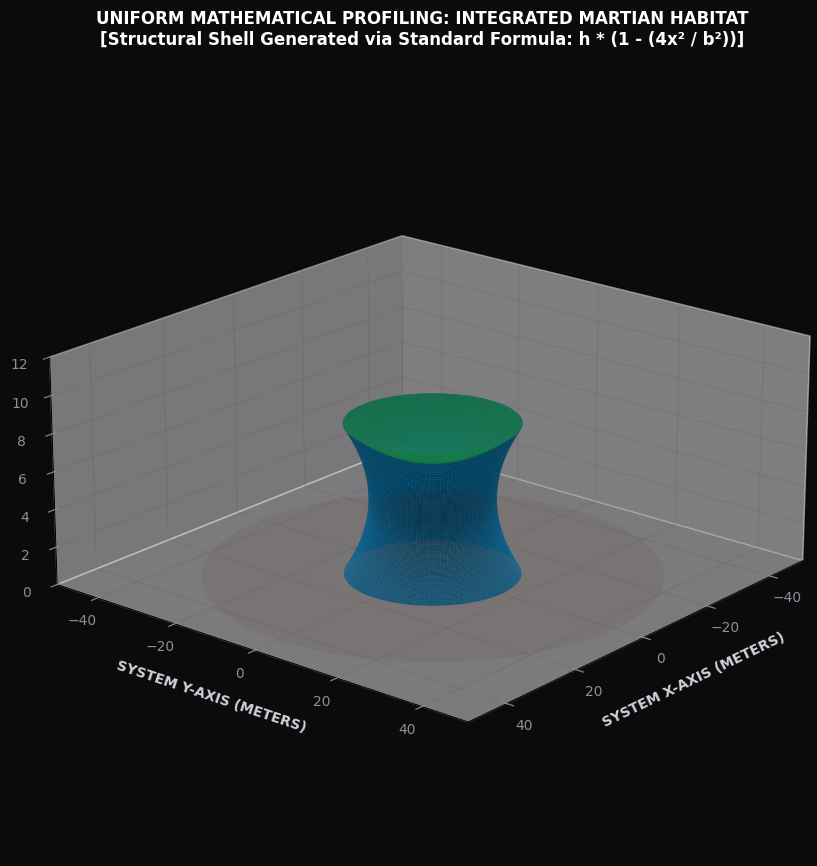

In [1]:
# Enable interactive 3D rendering in Google Colab or Jupyter Notebooks
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt

# =========================================================================
# 1. STRUCTURAL DESIGN PARAMETERS (UNIFORM PARABOLIC SCALING)
# =========================================================================
b_r = 34.0   # Base width / Max outer diameter of the habitat (34 meters)
h_w = 8.0    # Reference height boundary for the side wall (8 meters)
h_r = 1.8    # Shallow roof arch depth parameter (1.8 meters)
b_w = 4.8    # Wall constriction factor (Inward boundary curve depth)

# =========================================================================
# 2. FINITE ELEMENT GRID ARRAYS
# =========================================================================
theta_vals = np.linspace(0, 2 * np.pi, 250)  # Complete 360-degree axisymmetry
z_vals_wall = np.linspace(0, h_w, 150)        # Elevation nodes for the side wall
r_vals_roof = np.linspace(0, b_r / 2, 150)    # Radial distance nodes for the roof

# =========================================================================
# 3. GEOMETRY ENGINE (APPLYING REQUESTED PARABOLIC EQUATION)
# =========================================================================

# --- A. SIDE WALL LAYER (EQUATION APPLIED TO HEIGHT PROFILE) ---
THETA_w, Z_w = np.meshgrid(theta_vals, z_vals_wall)

# Using your exact formula format: h * (1 - (4 * (x^2) / (b^2)))
# Here, 'x' becomes the distance from mid-height, and 'b' is total height h_w
mid_height_offset = Z_w - (h_w / 2)
wall_inward_profile = b_w * (1 - (4 * (mid_height_offset**2) / (h_w**2)))

# Subtracting profile from outer radius pulls the wall inward symmetrically
R_wall = (b_r / 2) - wall_inward_profile

X_wall = R_wall * np.cos(THETA_w)
Y_wall = R_wall * np.sin(THETA_w)


# --- B. ROOF LAYER (EQUATION APPLIED TO RADIAL PROFILE) ---
R_r, THETA_r = np.meshgrid(r_vals_roof, theta_vals)

# Using your exact formula format: h * (1 - (4 * (x^2) / (b^2)))
# Here, 'x' is the radial distance R_r, and 'b' is total width b_r
# Subtracting from h_w keeps the outer edges perfectly locked to the wall boundary
Z_roof = h_w - h_r * (1 - (4 * (R_r**2) / (b_r**2)))

X_roof = R_r * np.cos(THETA_r)
Y_roof = R_r * np.sin(THETA_r)

# =========================================================================
# 4. RENDER LAYERS & MESH GENERATION
# =========================================================================
fig = plt.figure(figsize=(15, 10), facecolor='#0b0b0e')  # Tactical console backdrop
ax = fig.add_subplot(111, projection='3d')
ax.set_facecolor('#0b0b0e')

# Layer I: Faded Martian Base Layer (alpha=0.08 for minimal background noise)
r_mars = np.linspace(0, b_r * 1.3, 100)
THETA_m, R_m = np.meshgrid(theta_vals, r_mars)
X_mars = R_m * np.cos(THETA_m)
Y_mars = R_m * np.sin(THETA_m)
Z_mars = np.zeros_like(X_mars)
ax.plot_surface(X_mars, Y_mars, Z_mars, color='#b25329', alpha=0.08, edgecolor='none', rstride=4, cstride=4)

# Layer II: Structural Blue Inward Wall Shell
ax.plot_surface(X_wall, Y_wall, Z_w, color='#0088cc', alpha=0.85, edgecolor='none', rstride=2, cstride=2)

# Layer III: Connected Green Shallow Hanging Roof Shell
ax.plot_surface(X_roof, Y_roof, Z_roof, color='#21a357', alpha=0.9, edgecolor='none', rstride=2, cstride=2)

# =========================================================================
# 5. SCIENTIFIC VISUAL TUNING
# =========================================================================
ax.tick_params(colors='#8e8e93', labelsize=10)
ax.set_xlabel('SYSTEM X-AXIS (METERS)', color='#d1d1d6', fontsize=10, fontweight='bold', labelpad=12)
ax.set_ylabel('SYSTEM Y-AXIS (METERS)', color='#d1d1d6', fontsize=10, fontweight='bold', labelpad=12)
ax.set_zlabel('ELEVATION Z-AXIS (METERS)', color='#d1d1d6', fontsize=10, fontweight='bold', labelpad=12)

plt.title('UNIFORM MATHEMATICAL PROFILING: INTEGRATED MARTIAN HABITAT\n'
          '[Structural Shell Generated via Standard Formula: h * (1 - (4x² / b²))]',
          color='#ffffff', fontsize=12, fontweight='bold', pad=30, loc='center')

# Configuration parameters for visual layout normalization
ax.view_init(elev=20, azim=40)
ax.set_zlim(0, h_w + 4)
ax.set_box_aspect([1, 1, 0.45])

# Clean, low-density grid lines
ax.xaxis._axinfo["grid"]['color'] = (0.2, 0.2, 0.2, 0.1)
ax.yaxis._axinfo["grid"]['color'] = (0.2, 0.2, 0.2, 0.1)
ax.zaxis._axinfo["grid"]['color'] = (0.2, 0.2, 0.2, 0.1)

plt.show()
